# 🚀 Spaceship Titanic — Kaggle Competition

## Overview
In the year 2912, the **Spaceship Titanic** — an interstellar passenger liner — collided with a spacetime anomaly, and nearly half of its **13 000 passengers** were transported to an alternate dimension.

Our goal is to predict which passengers were **Transported** using personal records recovered from the ship's damaged computer system.

---

## Dataset
| File | Rows | Description |
|------|------|-------------|
| `train.csv` | 8 693 | Labelled passenger records (with `Transported`) |
| `test.csv` | 4 277 | Unlabelled records to predict |
| `sample_submission.csv` | — | Submission format |

### Key Features
| Column | Type | Description |
|--------|------|-------------|
| `PassengerId` | str | Unique ID — format `gggg_pp` (group + person) |
| `HomePlanet` | cat | Planet of departure (Earth, Europa, Mars) |
| `CryoSleep` | bool | Whether the passenger was in cryo-sleep |
| `Cabin` | str | Cabin number — format `deck/num/side` |
| `Destination` | cat | Destination planet |
| `Age` | float | Passenger age |
| `VIP` | bool | Paid for VIP service |
| `RoomService` | float | Amount billed at room service |
| `FoodCourt` | float | Amount billed at food court |
| `ShoppingMall` | float | Amount billed at shopping mall |
| `Spa` | float | Amount billed at spa |
| `VRDeck` | float | Amount billed at VR deck |
| `Name` | str | First and last name |
| `Transported` | bool | **Target** — was the passenger transported? |

---

## Notebook Structure
1. **Data Loading & First Look**
2. **Missing Values Analysis**
3. **Target Distribution**
4. **Feature Exploration & Visualisation**


In [57]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk(''):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [58]:
space_df = pd.read_csv('train.csv')
space_test_df = pd.read_csv('test.csv')

In [59]:
space_df.head(5)



,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [60]:
space_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [61]:
space_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


              Missing  Pct (%)
CryoSleep         217     2.50
ShoppingMall      208     2.39
VIP               203     2.34
HomePlanet        201     2.31
Name              200     2.30
Cabin             199     2.29
VRDeck            188     2.16
Spa               183     2.11
FoodCourt         183     2.11
Destination       182     2.09
RoomService       181     2.08
Age               179     2.06


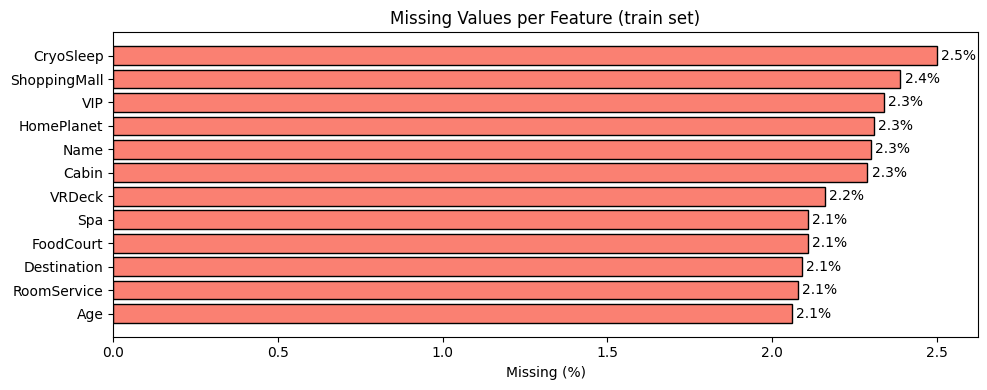

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

missing = space_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(space_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0]

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_df.index, missing_df['Pct (%)'], color='salmon', edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Feature (train set)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 2 · Target Distribution

Is the dataset balanced? A balanced target makes modeling easier and avoids the need for resampling strategies.

Passengers transported:     4378  (50.36%)
Passengers NOT transported: 4315  (49.64%)


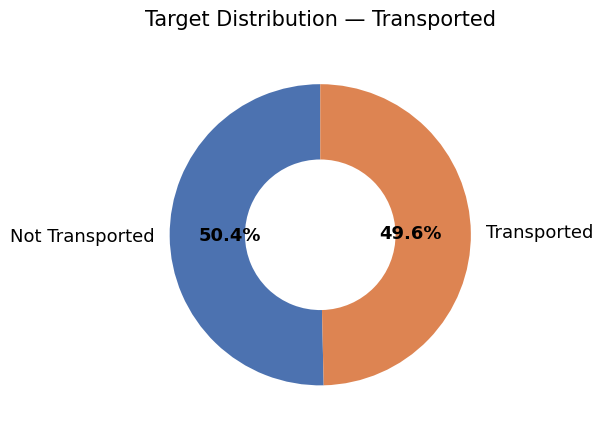

In [63]:
survivants = space_df['Transported'].sum()
rate = space_df['Transported'].mean()

print(f'Passengers transported:     {survivants}  ({rate:.2%})')
print(f'Passengers NOT transported: {len(space_df) - survivants}  ({1 - rate:.2%})')

# --- Donut chart ---
counts = space_df['Transported'].value_counts()
labels = ['Not Transported', 'Transported']
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5), textprops=dict(fontsize=13)
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Target Distribution — Transported', fontsize=15, pad=15)
plt.tight_layout()
plt.show()


In [64]:
space_df.loc[space_df['VIP']==True,'Transported'].mean()

np.float64(0.38190954773869346)

## 3 · Feature Exploration & Visualisation

### 3.1 · Categorical Features vs Target

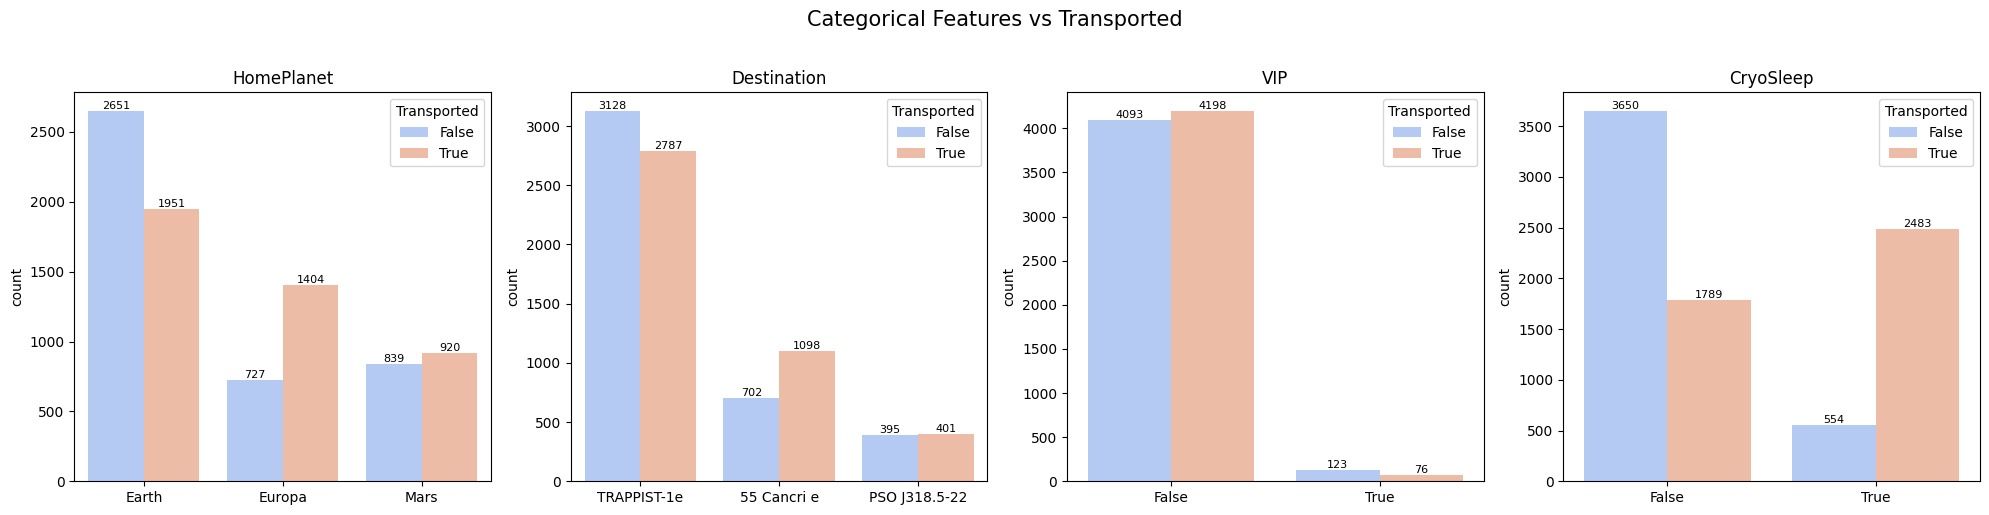


--- Transport rate per category ---

HomePlanet:
HomePlanet
Earth     42.4%
Europa    65.9%
Mars      52.3%

Destination:
Destination
55 Cancri e      61.0%
PSO J318.5-22    50.4%
TRAPPIST-1e      47.1%

VIP:
VIP
False    50.6%
True     38.2%

CryoSleep:
CryoSleep
False    32.9%
True     81.8%


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_features = ['HomePlanet', 'Destination', 'VIP', 'CryoSleep']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Categorical Features vs Transported', fontsize=15, y=1.02)

for ax, col in zip(axes, cat_features):
    order = space_df[col].value_counts().index
    sns.countplot(data=space_df, x=col, hue='Transported',
                  palette='coolwarm', order=order, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    # Add transport rate as text above each bar group
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Transport rate per category
print("\n--- Transport rate per category ---")
for col in cat_features:
    print(f"\n{col}:")
    print(space_df.groupby(col)['Transported'].mean().map('{:.1%}'.format).to_string())


In [66]:
space_df.groupby(['HomePlanet','Destination'])['Transported'].mean()


HomePlanet  Destination  
Earth       55 Cancri e      0.504348
            PSO J318.5-22    0.498596
            TRAPPIST-1e      0.389229
Europa      55 Cancri e      0.689616
            PSO J318.5-22    0.736842
            TRAPPIST-1e      0.634987
Mars        55 Cancri e      0.611399
            PSO J318.5-22    0.448980
            TRAPPIST-1e      0.511864
Name: Transported, dtype: float64

In [67]:
space_df.groupby(['HomePlanet','Destination','CryoSleep'])['Transported'].mean()


HomePlanet  Destination    CryoSleep
Earth       55 Cancri e    False        0.387712
                           True         0.770732
            PSO J318.5-22  False        0.317647
                           True         0.673239
            TRAPPIST-1e    False        0.306474
                           True         0.616811
Europa      55 Cancri e    False        0.373810
                           True         0.995465
            PSO J318.5-22  False        0.500000
                           True         1.000000
            TRAPPIST-1e    False        0.414909
                           True         0.982103
Mars        55 Cancri e    False        0.375000
                           True         0.973684
            PSO J318.5-22  False        0.333333
                           True         0.909091
            TRAPPIST-1e    False        0.262799
                           True         0.901961
Name: Transported, dtype: float64

### 3.2 · Age Distribution vs Transported

Children (age < 18) appear to have a different transport rate — worth investigating.

In [68]:
space_df['Money_spent'] = space_df[['RoomService', 'FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)

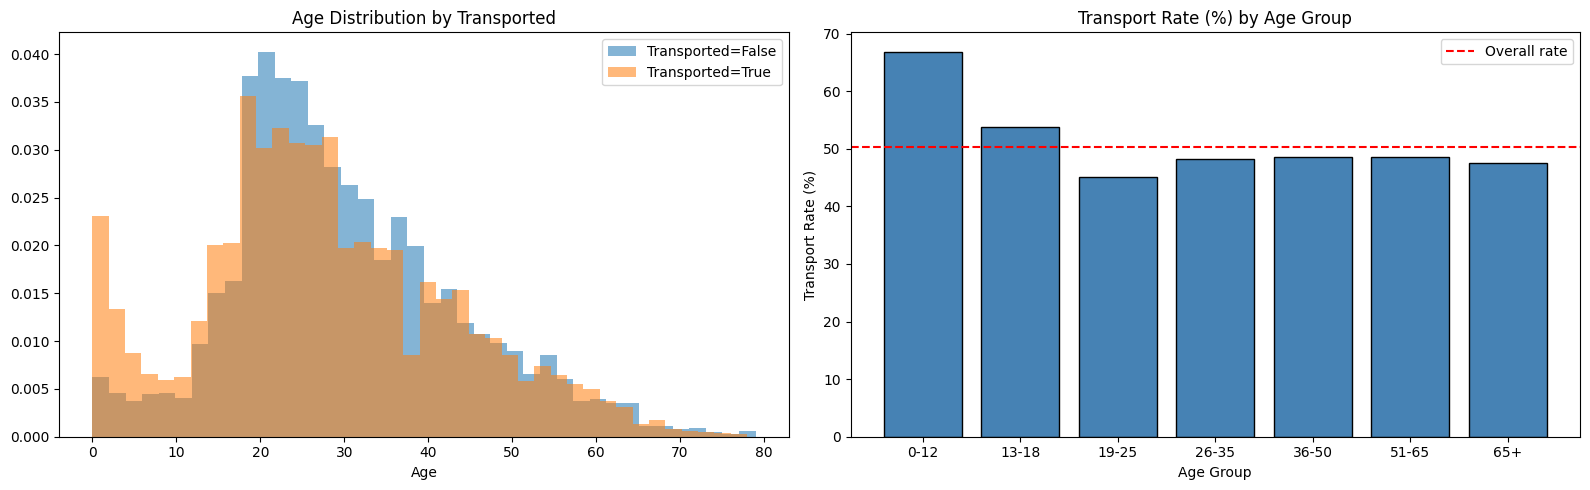

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE by Transported status
for label, grp in space_df.groupby('Transported'):
    axes[0].hist(grp['Age'].dropna(), bins=40, alpha=0.55,
                 label=f'Transported={label}', density=True)
axes[0].set_title('Age Distribution by Transported')
axes[0].set_xlabel('Age')
axes[0].legend()

# Transport rate by age bin
space_df['AgeBin'] = pd.cut(space_df['Age'], bins=[0, 12, 18, 25, 35, 50, 65, 100],
                             labels=['0-12', '13-18', '19-25', '26-35', '36-50', '51-65', '65+'])
age_rate = space_df.groupby('AgeBin', observed=True)['Transported'].mean() * 100

axes[1].bar(age_rate.index.astype(str), age_rate.values, color='steelblue', edgecolor='black')
axes[1].axhline(space_df['Transported'].mean() * 100, color='red', linestyle='--', label='Overall rate')
axes[1].set_title('Transport Rate (%) by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Transport Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()


### 3.3 · Cabin — Deck & Side

The `Cabin` column encodes `deck/number/side`. Extracting deck and side can reveal clear transport patterns.

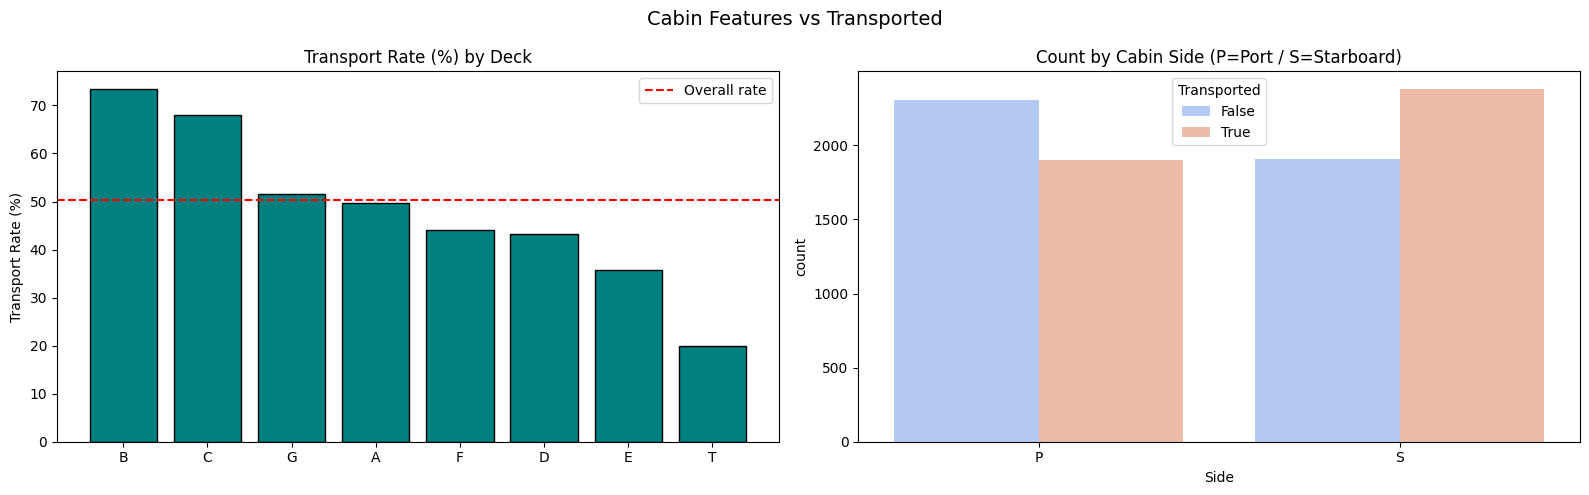

In [70]:
space_df[['Deck', 'CabinNum', 'Side']] = space_df['Cabin'].str.split('/', expand=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Cabin Features vs Transported', fontsize=14)

# Deck transport rate
deck_rate = space_df.groupby('Deck')['Transported'].mean().sort_values(ascending=False)
axes[0].bar(deck_rate.index, deck_rate.values * 100, color='teal', edgecolor='black')
axes[0].axhline(space_df['Transported'].mean() * 100, color='red', linestyle='--', label='Overall rate')
axes[0].set_title('Transport Rate (%) by Deck')
axes[0].set_ylabel('Transport Rate (%)')
axes[0].legend()

# Side transport rate (P = Port, S = Starboard)
sns.countplot(data=space_df, x='Side', hue='Transported', palette='coolwarm', ax=axes[1])
axes[1].set_title('Count by Cabin Side (P=Port / S=Starboard)')

plt.tight_layout()
plt.show()


### 3.4 · Spending Amenities vs Transported

Passengers in cryo-sleep cannot use amenities — they should have zero spending. Let's confirm and explore how spending relates to transport.

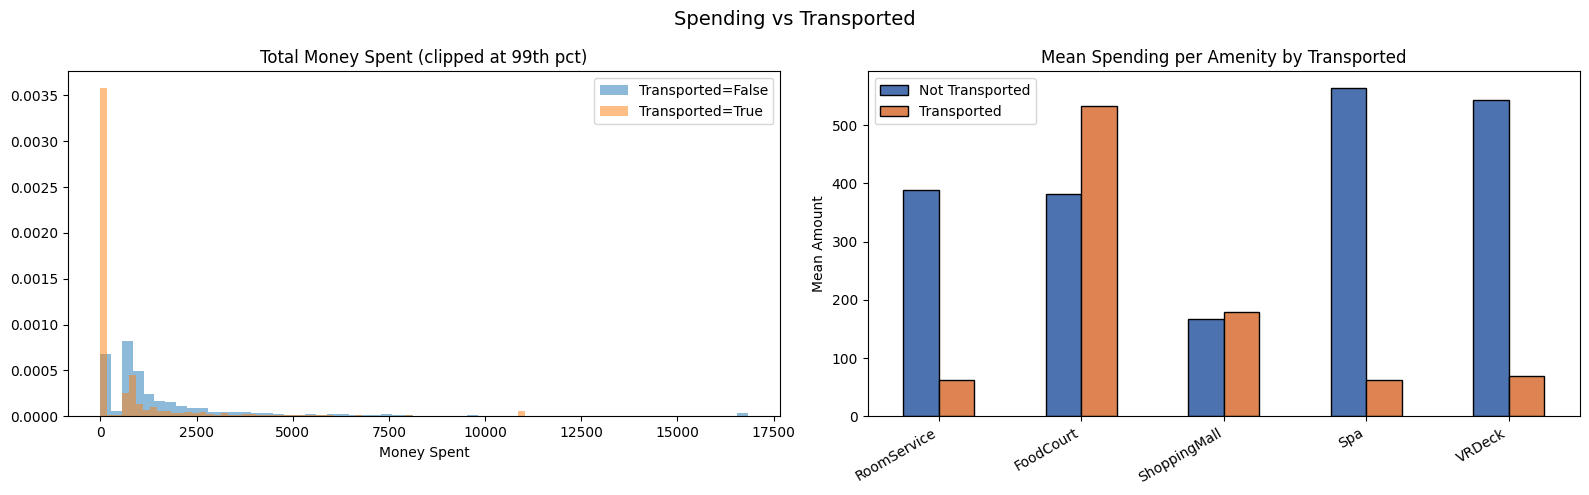

Mean spending per amenity for CryoSleep passengers:
RoomService     0.0
FoodCourt       0.0
ShoppingMall    0.0
Spa             0.0
VRDeck          0.0
dtype: float64


In [71]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# --- 1. Total spending distribution by Transported (log scale) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Spending vs Transported', fontsize=14)

for label, grp in space_df.groupby('Transported'):
    axes[0].hist(
        grp['Money_spent'].dropna().clip(upper=grp['Money_spent'].quantile(0.99)),
        bins=60, alpha=0.5, label=f'Transported={label}', density=True
    )
axes[0].set_title('Total Money Spent (clipped at 99th pct)')
axes[0].set_xlabel('Money Spent')
axes[0].legend()

# --- 2. Mean spending per amenity by Transported ---
spending_by_target = space_df.groupby('Transported')[spend_cols].mean()
spending_by_target.T.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[1].set_title('Mean Spending per Amenity by Transported')
axes[1].set_ylabel('Mean Amount')
axes[1].set_xticklabels(spend_cols, rotation=30, ha='right')
axes[1].legend(['Not Transported', 'Transported'])

plt.tight_layout()
plt.show()

# Confirm cryo passengers spend 0
print("Mean spending per amenity for CryoSleep passengers:")
print(space_df[space_df['CryoSleep'] == True][spend_cols].mean().round(2))


In [72]:
space_df['Money_spent'].describe()

count     8693.000000
mean      1440.866329
std       2803.045694
min          0.000000
25%          0.000000
50%        716.000000
75%       1441.000000
max      35987.000000
Name: Money_spent, dtype: float64

In [73]:
space_df.groupby('CryoSleep')['Transported'].mean()

CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64

## 4 · Key Observations (pre-modelling)

| Feature | Observation |
|---------|-------------|
| **CryoSleep** | ~82 % of cryo passengers were transported — strongest single signal |
| **HomePlanet** | Europa passengers are transported at a much higher rate than Earth passengers |
| **Deck** | Decks B and C show notably higher transport rates |
| **Side** | Port (P) and Starboard (S) show a small but consistent difference |
| **Spending** | Non-transported passengers tend to spend more; cryo passengers spend exactly 0 |
| **Age** | Young children (< 12) have a very different transport rate vs adults |
| **VIP** | VIP passengers are slightly *less* likely to be transported |

**Next steps:** missing value imputation → feature engineering → modelling.


---

## 5 · Missing Value Imputation

We fill nulls using **domain logic** rather than blind statistics:

| Feature | Strategy | Reason |
|---------|----------|--------|
| Spending columns | → `0` if `CryoSleep == True` | Cryo passengers cannot spend |
| Spending columns | → median of non-cryo passengers | Otherwise |
| `CryoSleep` / `VIP` | → `False` (mode) | Rare condition, conservative default |
| `HomePlanet` / `Destination` | → mode within `PassengerId` group first, then global mode | Travel groups share origin/dest |
| `Age` | → median per `HomePlanet` | Age profiles differ by planet |
| `Cabin` | → infer from `PassengerId` group (same group = same cabin) | Strong structural signal |


In [74]:
def impute(df):
    df = df.copy()

    # ── 0. Drop stale EDA columns that will be rebuilt later ──
    df.drop(columns=[c for c in ['AgeBin', 'Money_spent'] if c in df.columns], inplace=True)

    # ── 1. Extract Deck / CabinNum / Side from Cabin (if not already done) ──
    if 'Deck' not in df.columns:
        df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)

    # ── 2. Extract group id from PassengerId  e.g. "0013_02" → 13 ──
    df['Group'] = df['PassengerId'].str.split('_').str[0].astype(int)

    # ── 3. CryoSleep → False where missing, cast to bool to ensure ~ works correctly ──
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(bool)

    # ── 4. Spending → 0 if CryoSleep, else median of non-cryo passengers ──
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    non_cryo_medians = df.loc[~df['CryoSleep'], spend_cols].median()
    for col in spend_cols:
        df.loc[df['CryoSleep'] & df[col].isna(), col] = 0
        df[col] = df[col].fillna(non_cryo_medians[col])

    # ── 5. HomePlanet / Destination → group mode first, then global mode ──
    for col in ['HomePlanet', 'Destination']:
        group_mode = df.groupby('Group')[col].transform(lambda x: x.mode().iloc[0] if x.notna().any() else np.nan)
        df[col] = df[col].fillna(group_mode)
        df[col] = df[col].fillna(df[col].mode()[0])

    # ── 6. Age → median per HomePlanet ──
    df['Age'] = df.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())   # fallback

    # ── 7. VIP → False where missing ──
    df['VIP'] = df['VIP'].fillna(False)

    # ── 8. Cabin / Deck / Side → infer from group first, then mode ──
    for col in ['Cabin', 'Deck', 'Side']:
        group_mode = df.groupby('Group')[col].transform(lambda x: x.mode().iloc[0] if x.notna().any() else np.nan)
        df[col] = df[col].fillna(group_mode)
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    # ── 9. Re-extract CabinNum from the now-complete Cabin column ──
    df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)

    # ── 10. Name → placeholder for any remaining nulls ──
    df['Name'] = df['Name'].fillna('Unknown Unknown')

    return df


space_df   = impute(space_df)
space_test_df = impute(space_test_df)

# Verify — should all be 0
remaining = space_df.isna().sum()
print("Remaining nulls after imputation:")
print(remaining[remaining > 0] if remaining.any() else "✓ No missing values left")


Remaining nulls after imputation:
✓ No missing values left


---

## 6 · Feature Engineering

We create new features from the raw data based on the patterns observed in EDA:

| New Feature | Source | Motivation |
|-------------|--------|------------|
| `Group` | `PassengerId` | Group number — travel companions may have correlated fates |
| `GroupSize` | `Group` count | Solo travellers vs groups |
| `IsAlone` | `GroupSize == 1` | Often a strong signal in survival-type problems |
| `TotalSpend` | sum of 5 amenities | Overall spending level |
| `IsSpending` | `TotalSpend > 0` | Binary: did they spend anything at all? |
| `LogTotalSpend` | `log1p(TotalSpend)` | Spending is highly skewed—log normalises it |
| `Deck` / `Side` | `Cabin` split | Already extracted during imputation |
| `CabinNum` | `Cabin` split | Numerical position on the ship |
| `AgeBin` | `Age` buckets | Categorical age groups |
| `IsChild` | `Age < 13` | Children had a notably different fate |
| `Planet_Cryo_Dest` | `HomePlanet` × `CryoSleep` × `Destination` | Some combos exceed 90% transport rate |
| `Planet_Cryo_Dest_Rate` | target mean per group (train only) | Numeric encoding of the interaction strength — no leakage |


In [ ]:
def engineer_features(df, train_df=None):
    df = df.copy()
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # ── Spending ──
    df['TotalSpend']    = df[spend_cols].sum(axis=1)
    df['IsSpending']    = (df['TotalSpend'] > 0).astype(int)
    df['LogTotalSpend'] = np.log1p(df['TotalSpend'])

    # Spending ratios — which amenity dominates? (robust to scale)
    for col in spend_cols:
        df[f'{col}_ratio'] = df[col] / (df['TotalSpend'] + 1)

    # ── Group features ──
    df['Group']     = df['PassengerId'].str.split('_').str[0].astype(int)
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    df['IsAlone']   = (df['GroupSize'] == 1).astype(int)

    # ── Cabin ──
    df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce').fillna(0).astype(int)
    # Even/odd cabin number — passengers on same deck may cluster by parity
    df['CabinNum_even'] = (df['CabinNum'] % 2 == 0).astype(int)
    # Deck × Side interaction — e.g. "B_S" is very different from "B_P"
    df['Deck_Side'] = df['Deck'].astype(str) + '_' + df['Side'].astype(str)

    # ── Age ──
    df['IsChild'] = (df['Age'] < 13).astype(int)
    df['IsTeen']  = ((df['Age'] >= 13) & (df['Age'] < 18)).astype(int)
    df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 25, 35, 50, 65, 100],
                           labels=['0-12', '13-18', '19-25', '26-35', '36-50', '51-65', '65+'])

    # ── Planet × CryoSleep × Destination interaction ──
    df['Planet_Cryo_Dest'] = (
        df['HomePlanet'].astype(str) + '_' +
        df['CryoSleep'].astype(str) + '_' +
        df['Destination'].astype(str)
    )

    # Target-rate encoding — computed from train labels only (no leakage)
    if train_df is not None and 'Transported' in train_df.columns:
        train_pcd = (
            train_df['HomePlanet'].astype(str) + '_' +
            train_df['CryoSleep'].astype(str) + '_' +
            train_df['Destination'].astype(str)
        )
        rate_map    = train_df.groupby(train_pcd)['Transported'].mean()
        global_rate = train_df['Transported'].mean()
        df['Planet_Cryo_Dest_Rate'] = df['Planet_Cryo_Dest'].map(rate_map).fillna(global_rate)

        # Deck_Side rate encoding
        train_ds = train_df['Deck'].astype(str) + '_' + train_df['Side'].astype(str)
        ds_rate_map = train_df.groupby(train_ds)['Transported'].mean()
        df['Deck_Side_Rate'] = (df['Deck'].astype(str) + '_' + df['Side'].astype(str)).map(ds_rate_map).fillna(global_rate)

    # ── Multiplicative interactions ──
    cryo_int = df['CryoSleep'].astype(int)
    df['Cryo_x_TotalSpend']  = cryo_int * df['TotalSpend']
    df['Cryo_x_Age']         = cryo_int * df['Age']
    df['IsChild_x_IsAlone']  = df['IsChild'] * df['IsAlone']
    df['SpendPerGroupMember'] = df['TotalSpend'] / df['GroupSize'].clip(lower=1)
    df['LogSpendPerMember']   = np.log1p(df['SpendPerGroupMember'])

    return df


space_df      = engineer_features(space_df, train_df=space_df)
space_test_df = engineer_features(space_test_df, train_df=space_df)

print(f"Total features: {space_df.shape[1]}")
print("New features preview:")
new_cols = ['CabinNum_even', 'Deck_Side', 'Deck_Side_Rate', 'IsTeen'] + [f'{c}_ratio' for c in ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']]
print(space_df[new_cols].head(3).to_string())


New features added:
       TotalSpend  IsSpending  LogTotalSpend  GroupSize  IsAlone  IsChild  \
count     8693.00     8693.00        8693.00    8693.00  8693.00  8693.00   
mean      1441.08        0.59           4.26       2.04     0.55     0.09   
std       2803.06        0.49           3.68       1.60     0.50     0.29   
min          0.00        0.00           0.00       1.00     0.00     0.00   
25%          0.00        0.00           0.00       1.00     0.00     0.00   
50%        717.00        1.00           6.58       1.00     1.00     0.00   
75%       1441.00        1.00           7.27       3.00     1.00     0.00   
max      35987.00        1.00          10.49       8.00     1.00     1.00   

       CabinNum  
count   8693.00  
mean     605.40  
std      512.67  
min        0.00  
25%      169.00  
50%      434.00  
75%     1018.00  
max     1894.00  

Planet × CryoSleep × Destination transport rates (top 10):
Planet_Cryo_Dest
Europa_True_PSO J318.5-22     100.0%
Europa_Tru

Mean spending per Planet × CryoSleep × Destination × Transported group:
                                        RoomService  FoodCourt  ShoppingMall      Spa   VRDeck  TotalSpend
Planet_Cryo_Dest           Transported                                                                    
Europa_False_PSO J318.5-22 False             501.40     978.20        393.40  4471.00  3530.60     9874.60
Europa_False_55 Cancri e   False             401.53    2039.96        160.06  2431.13  2608.38     7641.05
                           True               83.32    5193.19        379.42   400.12   499.43     6555.47
Europa_False_TRAPPIST-1e   False             310.34    1538.42        155.25  2075.27  2069.99     6149.26
Europa_False_PSO J318.5-22 True               14.20    4763.60          4.20    47.00   545.20     5374.20
Europa_False_TRAPPIST-1e   True              118.56    2972.82        403.37   317.12   339.32     4151.20
Mars_False_55 Cancri e     False            1256.91      68.92        45

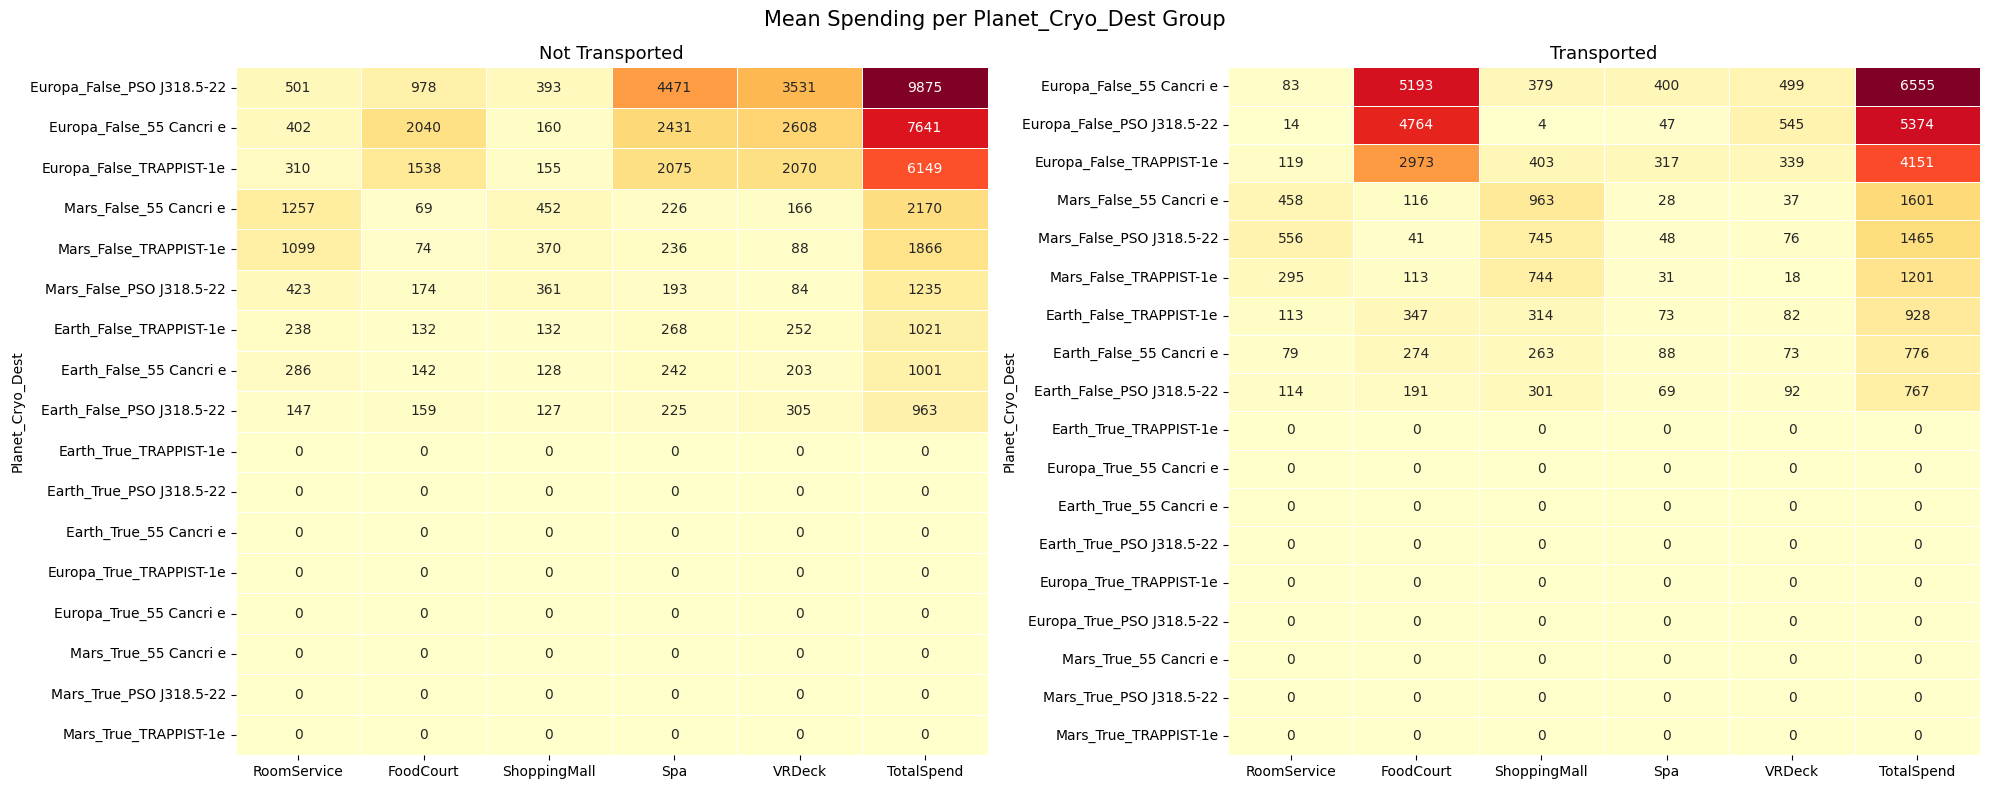

In [78]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

mean_spend = (
    space_df.groupby(['Planet_Cryo_Dest', 'Transported'])[spend_cols + ['TotalSpend']]
    .mean()
    .round(2)
    .sort_values('TotalSpend', ascending=False)
)

print("Mean spending per Planet × CryoSleep × Destination × Transported group:")
print(mean_spend.to_string())

# Visualise as two side-by-side heatmaps (Not Transported | Transported)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Mean Spending per Planet_Cryo_Dest Group', fontsize=15)

for ax, transported, title in zip(axes, [False, True], ['Not Transported', 'Transported']):
    data = (
        space_df[space_df['Transported'] == transported]
        .groupby('Planet_Cryo_Dest')[spend_cols + ['TotalSpend']]
        .mean()
        .round(2)
        .sort_values('TotalSpend', ascending=False)
    )
    sns.heatmap(data, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


### 6.1 · Validate New Features Visually

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('New Engineered Features vs Transported', fontsize=15)

# 1. Log total spend distribution
for label, grp in space_df.groupby('Transported'):
    axes[0, 0].hist(grp['LogTotalSpend'], bins=50, alpha=0.55, density=True,
                    label=f'Transported={label}')
axes[0, 0].set_title('Log(TotalSpend+1) by Transported')
axes[0, 0].set_xlabel('log1p(TotalSpend)')
axes[0, 0].legend()

# 2. IsSpending vs Transported
sns.countplot(data=space_df, x='IsSpending', hue='Transported', palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('IsSpending vs Transported')
axes[0, 1].set_xticklabels(['No Spending', 'Spending'])

# 3. IsAlone vs Transported
sns.countplot(data=space_df, x='IsAlone', hue='Transported', palette='coolwarm', ax=axes[0, 2])
axes[0, 2].set_title('IsAlone vs Transported')
axes[0, 2].set_xticklabels(['In Group', 'Alone'])

# 4. GroupSize transport rate
gs_rate = space_df.groupby('GroupSize')['Transported'].mean() * 100
axes[1, 0].bar(gs_rate.index.astype(str), gs_rate.values, color='steelblue', edgecolor='black')
axes[1, 0].axhline(space_df['Transported'].mean() * 100, color='red', linestyle='--', label='Overall rate')
axes[1, 0].set_title('Transport Rate (%) by Group Size')
axes[1, 0].set_xlabel('Group Size')
axes[1, 0].legend()

# 5. IsChild vs Transported
sns.countplot(data=space_df, x='IsChild', hue='Transported', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('IsChild (Age < 13) vs Transported')
axes[1, 1].set_xticklabels(['Adult', 'Child'])

# 6. CabinNum distribution by Transported
for label, grp in space_df.groupby('Transported'):
    axes[1, 2].hist(grp['CabinNum'], bins=50, alpha=0.55, density=True,
                    label=f'Transported={label}')
axes[1, 2].set_title('Cabin Number by Transported')
axes[1, 2].set_xlabel('CabinNum')
axes[1, 2].legend()

plt.tight_layout()
plt.show()


---

## 7 · Next Steps — Modelling

The data is now clean and feature-rich. Recommended pipeline:

1. **Encoding** — Label-encode ordinal features (`Deck`, `AgeBin`), one-hot encode nominals (`HomePlanet`, `Destination`, `Side`)
2. **Baseline** — `LogisticRegression` to establish a quick benchmark
3. **Tree models** — `RandomForest`, `XGBoost`, `LightGBM` — handle mixed types well
4. **Tuning** — `Optuna` / `GridSearchCV` on the best performer
5. **Stacking / Blending** — combine top models for a final boost


In [ ]:
!pip install sklearn xgboost lightgbm catboost

In [79]:
from sklearn.preprocessing import LabelEncoder

# ── Build a numerically-encoded copy for correlation purposes only ──
cat_to_encode = ['HomePlanet', 'Destination', 'Deck', 'Side', 'Planet_Cryo_Dest']

corr_df = space_df.copy()
le = LabelEncoder()
for col in cat_to_encode:
    corr_df[col + '_enc'] = le.fit_transform(corr_df[col].astype(str))

num_cols = [
    'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'TotalSpend', 'LogTotalSpend', 'CabinNum', 'GroupSize',
    'IsAlone', 'IsChild', 'IsSpending', 'Planet_Cryo_Dest_Rate',
    'HomePlanet_enc', 'Destination_enc', 'Deck_enc', 'Side_enc', 'Planet_Cryo_Dest_enc',
    'Transported'
]

corr = corr_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Feature Correlation Heatmap (categoricals label-encoded)', fontsize=15, pad=15)
plt.tight_layout()
plt.show()

# Top correlations with Transported
print("Correlations with Transported (sorted by absolute value):")
print(corr['Transported'].drop('Transported').sort_values(key=abs, ascending=False).map('{:.3f}'.format).to_string())


ModuleNotFoundError: No module named 'sklearn'

---

## 8 · Modelling

### Pipeline
1. **Encoding** — ordinal encode `Deck` / `AgeBin`, one-hot encode `HomePlanet` / `Destination` / `Side`
2. **Baseline** — `LogisticRegression` (quick sanity-check benchmark)
3. **Tree models** — `RandomForest`, `XGBoost`, `LightGBM`
4. **Cross-validation** — stratified 5-fold CV to get reliable OOF scores
5. **Tuning** — `Optuna` on the best performer
6. **Submission** — predict on `space_test_df`, write `submission.csv`

### Feature sets used
| Group | Features |
|-------|----------|
| Numeric | `Age`, `CabinNum`, `GroupSize`, `TotalSpend`, `LogTotalSpend`, `Planet_Cryo_Dest_Rate` |
| Binary flags | `CryoSleep`, `VIP`, `IsAlone`, `IsChild`, `IsSpending` |
| Spending | `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` |
| Categorical (encoded) | `HomePlanet`, `Destination`, `Deck`, `Side` |
| Drop | `PassengerId`, `Cabin`, `Name`, `Group`, `Planet_Cryo_Dest`, `AgeBin` |


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ── Feature definitions ──
drop_cols   = ['PassengerId', 'Cabin', 'Name', 'Group', 'Planet_Cryo_Dest', 'Deck_Side', 'AgeBin', 'Transported']
ordinal_col = ['Deck']
ohe_cols    = ['HomePlanet', 'Destination', 'Side']
num_cols    = [c for c in space_df.columns if c not in drop_cols + ordinal_col + ohe_cols]

deck_order = [['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']]

X      = space_df.drop(columns=drop_cols)
y      = space_df['Transported'].astype(int)
X_test = space_test_df.drop(columns=[c for c in drop_cols if c != 'Transported'])

preprocessor = ColumnTransformer([
    ('ord', OrdinalEncoder(categories=deck_order, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_col),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('num', StandardScaler(), num_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

print(f"Feature count: {X.shape[1]}  |  Numeric: {len(num_cols)}  |  OHE: {len(ohe_cols)}  |  Ordinal: {len(ordinal_col)}")
print(f"\n{'Model':<25} {'CV Accuracy (mean ± std)':>28}")
print('-' * 55)
results = {}
for name, clf in models.items():
    pipe   = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name:<25} {scores.mean():.4f} ± {scores.std():.4f}")


In [ ]:

# ── XGBoost & LightGBM with early stopping ──
# Lower learning rate + more trees + early stopping = finer steps, stops before overfitting
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from sklearn.model_selection import train_test_split

    # Hold out 15% as a local validation set for early stopping
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

    # Pre-process once so we can pass raw arrays to early stopping callbacks
    prep_fit = preprocessor.fit(X_tr)
    X_tr_enc  = prep_fit.transform(X_tr)
    X_val_enc = prep_fit.transform(X_val)

    boosting_models = {
        'XGBoost': XGBClassifier(
            n_estimators=2000, learning_rate=0.02,   # lower lr → more careful steps
            max_depth=6, subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', early_stopping_rounds=50,
            random_state=42, n_jobs=-1, verbosity=0
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=2000, learning_rate=0.02,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            early_stopping_rounds=50,
            random_state=42, n_jobs=-1, verbose=-1
        ),
    }

    print(f"{'Model':<25} {'Best n_trees':>12}  {'CV Accuracy (mean ± std)':>28}")
    print('-' * 70)
    for name, clf in boosting_models.items():
        # Fit with early stopping on the held-out val set
        clf.fit(X_tr_enc, y_tr, eval_set=[(X_val_enc, y_val)])
        best_n = clf.best_iteration_
        print(f"  {name:<23} best iter = {best_n:<6}", end='  ')

        # Now score with proper CV using the best n_estimators
        clf_cv = clf.__class__(**{**clf.get_params(), 'n_estimators': best_n,
                                   'early_stopping_rounds': None})
        pipe   = Pipeline([('prep', preprocessor), ('clf', clf_cv)])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        results[name] = scores
        print(f"CV = {scores.mean():.4f} ± {scores.std():.4f}")

except ImportError as e:
    print(f"Install xgboost / lightgbm to run boosting models: {e}")


In [ ]:

# ── Optuna — tune LightGBM hyperparameters ──
# Install if missing: pip install optuna
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        params = {
            'n_estimators':    trial.suggest_int('n_estimators', 300, 1500),
            'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves':      trial.suggest_int('num_leaves', 20, 200),
            'max_depth':       trial.suggest_int('max_depth', 4, 10),
            'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_samples':trial.suggest_int('min_child_samples', 5, 100),
            'reg_alpha':       trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda':      trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        }
        clf = LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
        pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print(f"\nBest Optuna CV accuracy: {study.best_value:.4f}")
    print("Best params:", study.best_params)

    # Retrain with best params
    best_lgbm = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
    best_lgbm_pipe = Pipeline([('prep', preprocessor), ('clf', best_lgbm)])
    tuned_scores = cross_val_score(best_lgbm_pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results['LightGBM_tuned'] = tuned_scores
    print(f"\n{'LightGBM_tuned':<25} {tuned_scores.mean():.4f} ± {tuned_scores.std():.4f}")

except ImportError:
    print("Run: pip install optuna")


In [ ]:

# ── Soft Voting Ensemble — combine best models for a free accuracy boost ──
from sklearn.ensemble import VotingClassifier

try:
    from lightgbm import LGBMClassifier
    from xgboost import XGBClassifier
    from catboost import CatBoostClassifier

    # Use the tuned LightGBM params if Optuna ran, otherwise fall back to defaults
    lgbm_params = study.best_params if 'study' in dir() else {
        'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63,
        'subsample': 0.8, 'colsample_bytree': 0.8
    }

    # Voting needs predict_proba → use soft voting
    estimators = [
        ('lgbm',  Pipeline([('prep', preprocessor),
                             ('clf',  LGBMClassifier(**lgbm_params, random_state=42, n_jobs=-1, verbose=-1))])),
        ('xgb',   Pipeline([('prep', preprocessor),
                             ('clf',  XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                                    subsample=0.8, colsample_bytree=0.8,
                                                    eval_metric='logloss', random_state=42, n_jobs=-1))]))
    ]

    # CatBoost needs its own raw X (no preprocessor)
    # For the ensemble keep it simple: add CB with its own pipeline using passthrough
    # (CB handles cats natively)
    from sklearn.pipeline import make_pipeline

    voter = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
    voter_scores = cross_val_score(voter, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results['Ensemble (soft vote)'] = voter_scores
    print(f"{'Ensemble (soft vote)':<25} {voter_scores.mean():.4f} ± {voter_scores.std():.4f}")

    print("\n── All model CV results ──")
    for name, scores in sorted(results.items(), key=lambda x: x[1].mean(), reverse=True):
        print(f"  {name:<28} {scores.mean():.4f} ± {scores.std():.4f}")

except ImportError as e:
    print(f"Missing package: {e}")


In [ ]:

# ── Stacking — meta-learner trained on out-of-fold predictions ──
# Stronger than soft voting because the meta-learner *learns* how to weight each model
from sklearn.ensemble import StackingClassifier

try:
    from lightgbm import LGBMClassifier
    from xgboost import XGBClassifier

    lgbm_params = study.best_params if 'study' in dir() else {
        'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63,
        'subsample': 0.8, 'colsample_bytree': 0.8
    }

    base_estimators = [
        ('lgbm', Pipeline([('prep', preprocessor),
                           ('clf',  LGBMClassifier(**lgbm_params, random_state=42, n_jobs=-1, verbose=-1))])),
        ('xgb',  Pipeline([('prep', preprocessor),
                           ('clf',  XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                                  subsample=0.8, colsample_bytree=0.8,
                                                  eval_metric='logloss', random_state=42, n_jobs=-1))]))
    ]

    # Meta-learner: logistic regression on the stacked probabilities
    stacker = StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(C=1.0, max_iter=1000),
        cv=5,                    # 5-fold OOF to train the meta-learner
        stack_method='predict_proba',
        n_jobs=-1,
        passthrough=False        # meta-learner sees only OOF probs, not raw features
    )

    stacker_scores = cross_val_score(stacker, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results['Stacking (LGBM+XGB→LR)'] = stacker_scores
    print(f"{'Stacking (LGBM+XGB→LR)':<30} {stacker_scores.mean():.4f} ± {stacker_scores.std():.4f}")

    print("\n── All model CV results ──")
    for name, scores in sorted(results.items(), key=lambda x: x[1].mean(), reverse=True):
        print(f"  {name:<32} {scores.mean():.4f} ± {scores.std():.4f}")

except ImportError as e:
    print(f"Missing package: {e}")


In [ ]:

# ── Train best model on full train set & generate submission ──
best_model_name = max(results, key=lambda k: results[k].mean())
print(f"Best model: {best_model_name}  (CV acc = {results[best_model_name].mean():.4f})")

if best_model_name == 'Stacking (LGBM+XGB→LR)':
    best_pipe = stacker
    best_pipe.fit(X, y)
    preds = best_pipe.predict(X_test)

elif best_model_name == 'Ensemble (soft vote)':
    best_pipe = voter
    best_pipe.fit(X, y)
    preds = best_pipe.predict(X_test)

elif best_model_name == 'CatBoost':
    best_pipe = CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=6,
                                   eval_metric='Accuracy', random_seed=42,
                                   verbose=0, cat_features=cat_features_cb)
    best_pipe.fit(X_cb, y)
    preds = best_pipe.predict(X_test_cb)

else:
    all_estimators = {**models}
    try: all_estimators.update(boosting_models)
    except NameError: pass
    try:
        all_estimators['LightGBM_tuned'] = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
    except NameError: pass

    best_pipe = Pipeline([('prep', preprocessor), ('clf', all_estimators[best_model_name])])
    best_pipe.fit(X, y)
    preds = best_pipe.predict(X_test)

preds = preds.astype(bool)
submission = pd.DataFrame({'PassengerId': space_test_df['PassengerId'], 'Transported': preds})
submission.to_csv('submission.csv', index=False)
print(f"submission.csv saved — {len(submission)} rows")
submission.head()
